<a href="https://colab.research.google.com/github/gnoejh/AIBookGitHub/blob/main/6_skippass.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Residual Connections (Skip Connections)

A Comprehensive Guide to Skip Connections in Neural Networks

## Introduction

Residual connections, also known as skip connections, represent one of the most significant breakthroughs in deep learning architecture design. Introduced in the groundbreaking ResNet paper by He et al. (2015), these connections revolutionized our ability to train extremely deep neural networks.

### The Deep Network Challenge

Before residual connections, training very deep networks was plagued by several fundamental problems:

- **Vanishing Gradients**: As networks became deeper, gradients would diminish exponentially during backpropagation, making it difficult to train early layers effectively.
- **Degradation Problem**: Surprisingly, even when vanishing gradients were addressed, deeper networks often performed worse than their shallower counterparts on both training and test sets.
- **Optimization Difficulties**: Deep networks were prone to getting stuck in poor local minima and suffered from slow convergence.

### The Skip Connection Solution

Residual connections elegantly solve these problems by providing alternative pathways for both forward and backward information flow. This seemingly simple modification has enabled the training of networks with hundreds or even thousands of layers, leading to significant improvements in computer vision, natural language processing, and many other domains.

## Historical Context and Impact

### Before ResNet (Pre-2015)
- **AlexNet (2012)**: 8 layers - breakthrough in deep learning
- **VGGNet (2014)**: 16-19 layers - deeper networks showed promise
- **Training Challenges**: Networks deeper than ~20 layers were difficult to train effectively

### After ResNet (2015-Present)
- **ResNet-50, ResNet-101, ResNet-152**: Successfully trained networks with 50-152 layers
- **Architectural Evolution**: Skip connections became fundamental building blocks
- **Widespread Adoption**: Integrated into DenseNet, Inception, Transformer architectures, and more

### Key Architectural Families Using Skip Connections

| Architecture | Year | Key Innovation | Depth Achieved |
|--------------|------|----------------|----------------|
| **ResNet** | 2015 | Identity skip connections | 152+ layers |
| **DenseNet** | 2017 | Dense skip connections (all previous layers) | 100+ layers |
| **ResNeXt** | 2017 | Grouped convolutions + residual connections | 101+ layers |
| **Transformers** | 2017 | Residual connections in attention blocks | Variable |
| **EfficientNet** | 2019 | Optimized residual blocks with compound scaling | Variable |

## Theoretical Foundation

### The Degradation Problem

One of the most counterintuitive discoveries in deep learning was that simply adding more layers to a network doesn't necessarily improve performance. In fact, researchers observed that deeper networks often performed worse than their shallower counterparts, even on training data. This phenomenon, known as the **degradation problem**, was distinct from overfitting.

### Why Skip Connections Work

Skip connections address the degradation problem through several mechanisms:

1. **Identity Mapping**: They provide a direct path for preserving information from earlier layers
2. **Gradient Highway**: They create shortcuts for gradients to flow backward more effectively
3. **Feature Reuse**: They allow the network to reuse features from multiple scales and levels of abstraction
4. **Easier Optimization**: They make the optimization landscape smoother and more conducive to gradient-based learning

## Mathematical Formulation

### Basic Residual Block

A residual block can be mathematically represented as:

$$\mathbf{y} = \mathcal{F}(\mathbf{x}, \{W_i\}) + \mathbf{x}$$

Where:
- $\mathbf{x}$ is the input to the residual block (feature map)
- $\mathcal{F}(\mathbf{x}, \{W_i\})$ represents the residual function learned by the stacked layers
- $\{W_i\}$ are the weights of the layers within the residual block
- $\mathbf{y}$ is the output of the residual block

### Key Insight: Learning Residuals vs. Direct Mapping

Instead of learning the desired underlying mapping $\mathcal{H}(\mathbf{x})$ directly, the residual block learns:

$$\mathcal{F}(\mathbf{x}) = \mathcal{H}(\mathbf{x}) - \mathbf{x}$$

This means $\mathcal{H}(\mathbf{x}) = \mathcal{F}(\mathbf{x}) + \mathbf{x}$, making it easier to learn the **residual** $\mathcal{F}(\mathbf{x})$ rather than the full transformation.

### Visual Representation

```mermaid
graph TB
    A[Input: x] --> B[Weight Layer]
    B --> C[Activation: ReLU]
    C --> D[Weight Layer]
    D --> E["+"]
    A --> E
    E --> F[Activation: ReLU]
    F --> G[Output: y]
    
    style A fill:#e1f5fe
    style G fill:#e8f5e8
    style E fill:#fff3e0
```

### Mathematical Benefits

1. **Identity Preservation**: If $\mathcal{F}(\mathbf{x}) = 0$, then $\mathbf{y} = \mathbf{x}$ (perfect identity mapping)
2. **Gradient Flow**: Gradients can flow directly through the skip connection, preventing vanishing
3. **Representation Power**: The network can learn both identity and complex transformations

## Gradient Flow Analysis

### Why Skip Connections Prevent Vanishing Gradients

Let's analyze how gradients flow through a network with skip connections. Consider a loss function $L$ and examine the gradient with respect to an earlier layer's activation $\mathbf{x}_l$.

For a traditional deep network:
$$\frac{\partial L}{\partial \mathbf{x}_l} = \frac{\partial L}{\partial \mathbf{x}_L} \prod_{i=l}^{L-1} \frac{\partial \mathbf{x}_{i+1}}{\partial \mathbf{x}_i}$$

This product can become very small (vanishing) or very large (exploding) as the network depth increases.

### With Residual Connections

For a residual network with skip connections, the gradient becomes:
$$\frac{\partial L}{\partial \mathbf{x}_l} = \frac{\partial L}{\partial \mathbf{x}_L} \left(1 + \frac{\partial}{\partial \mathbf{x}_l} \sum_{i=l}^{L-1} \mathcal{F}(\mathbf{x}_i, W_i)\right)$$

The key insight: **The gradient always has a direct path** (the "+1" term) that doesn't vanish, ensuring that information can flow backward through the network effectively.

### Empirical Evidence

Studies have shown that:
- **Without skip connections**: Gradient magnitudes decrease exponentially with depth
- **With skip connections**: Gradient magnitudes remain more stable across layers
- **Training dynamics**: Residual networks converge faster and reach better solutions

## Comparison of Residual Connection Variations

Residual connections (or skip connections) have been widely used to ease the training of deep neural networks. Below is a table comparing several common variations of residual connections, including their mathematical formulations and brief explanations.

| **Variation**            | **Mathematical Formulation**                                 | **Explanation**                                                                                                                                                        |
|--------------------------|--------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| **Standard Residual**    | $$ y = x + F(x) $$                                            | This is the basic residual block where the input \(x\) is directly added to the output of a function \(F(x)\) (e.g., a stack of conv, normalization, activation layers). |
| **Bottleneck Residual**  | $$ y = x + F(x) $$  with  $$F(x) = W_3 \, \sigma(W_2 \, \sigma(W_1 \, x))$$  | In this design, \(F(x)\) is computed using a bottleneck structure (typically 1×1, 3×3, and 1×1 convolutions) to reduce the number of parameters and computational cost while preserving representational power. |
| **Pre-activation Residual** | $$ y = x + F(x) $$  with  $$F(x) = F(\sigma(\text{BN}(x)))$$  | Here, the activation (typically ReLU) and batch normalization (BN) are applied *before* the convolutional layers inside \(F(x)\). This ordering improves gradient flow and regularizes the network.  |
| **Scaled Residual**      | $$ y = x + \alpha \, F(x) $$                                   | A scaling factor \(\alpha\) (often less than 1) is applied to the residual branch. This can help stabilize the training in extremely deep networks by controlling the magnitude of the residual contribution.  |
| **Projection Shortcut**  | $$ y = W_s \, x + F(x) $$                                      | When the dimensions of \(x\) and \(F(x)\) do not match, a projection matrix \(W_s\) (often implemented via a \(1 \times 1\) convolution) is used to transform \(x\) so that it can be added to \(F(x)\).  |

Each variation modifies the basic residual design to address different training challenges, such as mismatched dimensions, vanishing gradients, or computational efficiency. This table provides a concise comparison to help in selecting the appropriate residual connection variant for a given architecture.


# Backpropagation Derivation: With and Without Skip Connections

In this note, we derive the backpropagation equations for two very simple cases:

1. **Without a Skip Connection:**  
   $$ y = w x $$
2. **With a Skip Connection:**  
   $$ y = w x + x $$

We assume that during the backward pass we have the upstream gradient:
$$
\delta = \frac{\partial L}{\partial y},
$$
where $L(y)$ is the loss.

---

## Case 1: No Skip Connection

Consider:
$$
y = w x.
$$

### Forward Pass
- $ y = w x $

### Backward Pass

1. **Gradient with respect to $w$:**

   Using the chain rule:
   $$
   \frac{\partial L}{\partial w} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial w}.
   $$

   Since
   $$
   \frac{\partial y}{\partial w} = x,
   $$
   we have:
   $$
   \frac{\partial L}{\partial w} = \delta \, x.
   $$

2. **Gradient with respect to $x$:**

   Similarly,
   $$
   \frac{\partial L}{\partial x} = \frac{\partial L}{\partial y} \cdot \frac{\partial y}{\partial x}.
   $$

   And since
   $$
   \frac{\partial y}{\partial x} = w,
   $$
   we obtain:
   $$
   \frac{\partial L}{\partial x} = \delta \, w.
   $$

---

## Case 2: With a Skip Connection

Consider:
$$
y = w x + x.
$$

This can be factored as:
$$
y = (w + 1)x.
$$

### Forward Pass
- $ y = w x + x $

### Backward Pass

1. **Gradient with respect to $w$:**

   Notice that only the term $w x$ depends on $w$. Therefore:
   $$
   \frac{\partial y}{\partial w} = x.
   $$
   Applying the chain rule:
   $$
   \frac{\partial L}{\partial w} = \delta \, x.
   $$

2. **Gradient with respect to $x$:**

   Here, $y$ depends on $x$ in two ways:
   
   - From the $w x$ term:
     $$
     \frac{\partial (w x)}{\partial x} = w.
     $$
     
   - From the $x$ term (the skip connection):
     $$
     \frac{\partial x}{\partial x} = 1.
     $$
   
   Thus, summing both contributions:
   $$
   \frac{\partial y}{\partial x} = w + 1.
   $$
   
   And by the chain rule:
   $$
   \frac{\partial L}{\partial x} = \delta (w + 1).
   $$

---

## Comparison of the Two Cases

- **Gradient with respect to $w$:**

  - **No Skip:**  
    $$
    \frac{\partial L}{\partial w} = \delta \, x.
    $$
  - **With Skip:**  
    $$
    \frac{\partial L}{\partial w} = \delta \, x.
    $$
  
  The gradient with respect to the weight $w$ is the same in both cases.

- **Gradient with respect to $x$:**

  - **No Skip:**  
    $$
    \frac{\partial L}{\partial x} = \delta \, w.
    $$
  - **With Skip:**  
    $$
    \frac{\partial L}{\partial x} = \delta \, (w + 1).
    $$
  
  The key difference is in the gradient with respect to $x$:  
  with the skip connection, an additional term of $\delta$ is added. This extra gradient ensures that even if $w$ is small (or vanishing), the gradient backpropagated to $x$ does not vanish completely. This property is one of the key benefits of skip (residual) connections as it helps preserve gradient flow in deeper networks.

---


## Architecture Visualizations

### Standard Residual Block Architecture

```mermaid
graph TB
    A["Input: x"] --> B["Conv 3x3"]
    B --> C["Batch Norm"]
    C --> D["ReLU"]
    D --> E["Conv 3x3"]
    E --> F["Batch Norm"]
    F --> G["Add"]
    A --> G
    G --> H["ReLU"]
    H --> I["Output: F(x) + x"]
    
    style A fill:#e3f2fd
    style I fill:#e8f5e8
    style G fill:#fff3e0
    style B fill:#f3e5f5
    style E fill:#f3e5f5
```

### Comparison: Network Without vs. With Skip Connections

```mermaid
graph LR
    subgraph "Without Skip Connections"
        A1[Input] --> B1["Layer 1"]
        B1 --> C1["Layer 2"]
        C1 --> D1["Layer 3"]
        D1 --> E1["Layer 4"]
        E1 --> F1[Output]
    end
    
    subgraph "With Skip Connections"
        A2[Input] --> B2["Layer 1"]
        B2 --> C2["Layer 2"]
        C2 --> D2["Layer 3"]
        D2 --> E2["Layer 4"]
        E2 --> F2[Output]
        
        A2 -.-> C2
        B2 -.-> D2
        C2 -.-> E2
        D2 -.-> F2
    end
    
    style A1 fill:#ffebee
    style F1 fill:#ffebee
    style A2 fill:#e8f5e8
    style F2 fill:#e8f5e8
```

### Gradient Flow Visualization

```mermaid
graph BT
    subgraph "Forward Pass"
        F1["Layer 1"] --> F2["Layer 2"]
        F2 --> F3["Layer 3"]
        F3 --> F4["Layer 4"]
        F1 -.-> F3
        F2 -.-> F4
    end
    
    subgraph "Backward Pass (Gradients)"
        B4["∇L/∂Layer4"] --> B3["∇L/∂Layer3"]
        B3 --> B2["∇L/∂Layer2"]
        B2 --> B1["∇L/∂Layer1"]
        B4 -.-> B2
        B3 -.-> B1
    end
    
    style B4 fill:#ffcdd2
    style B3 fill:#ffcdd2
    style B2 fill:#ffcdd2
    style B1 fill:#ffcdd2
```

## Different Types of Skip Connections

### 1. Element-wise Addition (ResNet Style)
```mermaid
graph LR
    A[x] --> B["F(x)"]
    B --> C[Add]
    A --> C
    C --> D["F(x) + x"]
    
    style C fill:#fff3e0
```

### 2. Concatenation (DenseNet Style)
```mermaid
graph LR
    A[x] --> B["F(x)"]
    B --> C[Concat]
    A --> C
    C --> D["[x, F(x)]"]
    
    style C fill:#e8eaf6
```

### 3. Gated Skip Connection
```mermaid
graph LR
    A[x] --> B["F(x)"]
    A --> E["Gate: σ(G(x))"]
    B --> C["×"]
    E --> C
    A --> F["×"]
    E --> H["1-σ(G(x))"]
    H --> F
    C --> I[Add]
    F --> I
    I --> J[Output]
    
    style E fill:#fce4ec
    style C fill:#fff3e0
    style F fill:#fff3e0
    style I fill:#fff3e0
```

### 4. Multi-scale Skip Connections
```mermaid
graph TB
    A[Input] --> B["Conv 1x1"]
    A --> C["Conv 3x3"]  
    A --> D["Conv 5x5"]
    B --> E[Concat]
    C --> E
    D --> E
    A --> E
    E --> F[Output]
    
    style E fill:#e0f2f1
```

## Benefits of Residual Connections

| Benefit                | Description                                       |
|------------------------|---------------------------------------------------|
| Mitigate Vanishing Gradient | Helps gradients flow through the network more effectively during training. |
| Facilitate Deeper Networks | Enables the construction of much deeper neural networks without performance degradation. |
| Improve Accuracy          | Often results in better performance and accuracy in tasks such as image recognition. |

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ResidualBlock(nn.Module):
    """
    A basic residual block implementation following the ResNet architecture.
    
    The block implements: y = F(x) + x, where F(x) consists of:
    - Conv2d -> BatchNorm2d -> ReLU -> Conv2d -> BatchNorm2d
    
    Args:
        in_channels (int): Number of input channels
        out_channels (int): Number of output channels  
        stride (int): Stride for the first convolution (default: 1)
    """
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualBlock, self).__init__()
        
        # Main path: two 3x3 convolutions
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                              stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                              stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Shortcut connection: identity or projection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            # When dimensions don't match, use 1x1 conv for projection
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, 
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        # Store input for skip connection
        identity = x
        
        # Main path
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # Add skip connection
        out += self.shortcut(identity)
        
        # Final activation
        out = self.relu(out)
        
        return out

# Example: Create and test a residual block
if __name__ == '__main__':
    # Test with matching dimensions
    block1 = ResidualBlock(64, 64, stride=1)
    x1 = torch.randn(1, 64, 56, 56)
    y1 = block1(x1)
    print(f"Input shape: {x1.shape}")
    print(f"Output shape: {y1.shape}")
    print(f"Parameters: {sum(p.numel() for p in block1.parameters()):,}")
    
    print("\n" + "="*50 + "\n")
    
    # Test with dimension change (requires projection)
    block2 = ResidualBlock(64, 128, stride=2)
    x2 = torch.randn(1, 64, 56, 56)
    y2 = block2(x2)
    print(f"Input shape: {x2.shape}")
    print(f"Output shape: {y2.shape}")
    print(f"Stride=2 reduces spatial dimensions and projection increases channels")

Input shape: torch.Size([1, 64, 56, 56])
Output shape: torch.Size([1, 64, 56, 56])
Parameters: 73,984


Input shape: torch.Size([1, 64, 56, 56])
Output shape: torch.Size([1, 128, 28, 28])
Stride=2 reduces spatial dimensions and projection increases channels


In [11]:
class BottleneckBlock(nn.Module):
    """
    Bottleneck residual block used in deeper ResNet architectures (ResNet-50, 101, 152).
    
    Uses 1x1 -> 3x3 -> 1x1 convolutions to reduce computational cost while
    maintaining representational power.
    
    Args:
        in_channels (int): Number of input channels
        bottleneck_channels (int): Number of channels in the bottleneck (middle layer)
        out_channels (int): Number of output channels
        stride (int): Stride for the 3x3 convolution
    """
    
    def __init__(self, in_channels, bottleneck_channels, out_channels, stride=1):
        super(BottleneckBlock, self).__init__()
        
        # 1x1 conv to reduce dimensions
        self.conv1 = nn.Conv2d(in_channels, bottleneck_channels, kernel_size=1, bias=False)
        self.bn1 = nn.BatchNorm2d(bottleneck_channels)
        
        # 3x3 conv (main computation)
        self.conv2 = nn.Conv2d(bottleneck_channels, bottleneck_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(bottleneck_channels)
        
        # 1x1 conv to restore dimensions
        self.conv3 = nn.Conv2d(bottleneck_channels, out_channels, kernel_size=1, bias=False)
        self.bn3 = nn.BatchNorm2d(out_channels)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Shortcut connection
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
    
    def forward(self, x):
        identity = x
        
        # Bottleneck path: reduce -> process -> expand
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.relu(self.bn2(self.conv2(out)))
        out = self.bn3(self.conv3(out))
        
        # Add skip connection
        out += self.shortcut(identity)
        out = self.relu(out)
        
        return out

class PreActivationBlock(nn.Module):
    """
    Pre-activation residual block where BatchNorm and ReLU come before convolutions.
    This design improves gradient flow and has better regularization properties.
    
    Structure: BN -> ReLU -> Conv -> BN -> ReLU -> Conv
    """
    
    def __init__(self, in_channels, out_channels, stride=1):
        super(PreActivationBlock, self).__init__()
        
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                              stride=stride, padding=1, bias=False)
        
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                              stride=1, padding=1, bias=False)
        
        self.relu = nn.ReLU(inplace=True)
        
        # Shortcut
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False)
            )
    
    def forward(self, x):
        identity = x
        
        # Pre-activation design
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        
        out += self.shortcut(identity)
        
        return out

# Demonstration of different block types
if __name__ == '__main__':
    print("Comparing different residual block architectures:\n")
    
    # Input tensor
    x = torch.randn(1, 64, 32, 32)
    
    # Standard ResNet block
    standard_block = ResidualBlock(64, 64)
    standard_params = sum(p.numel() for p in standard_block.parameters())
    
    # Bottleneck block  
    bottleneck_block = BottleneckBlock(64, 16, 64)  # Reduce to 16 channels in bottleneck
    bottleneck_params = sum(p.numel() for p in bottleneck_block.parameters())
    
    # Pre-activation block
    preact_block = PreActivationBlock(64, 64)
    preact_params = sum(p.numel() for p in preact_block.parameters())
    
    print(f"Standard ResNet Block:      {standard_params:,} parameters")
    print(f"Bottleneck Block:           {bottleneck_params:,} parameters")
    print(f"Pre-activation Block:       {preact_params:,} parameters")
    
    print(f"\nBottleneck reduces parameters by {((standard_params - bottleneck_params) / standard_params * 100):.1f}%")

Comparing different residual block architectures:

Standard ResNet Block:      73,984 parameters
Bottleneck Block:           4,544 parameters
Pre-activation Block:       73,984 parameters

Bottleneck reduces parameters by 93.9%


Using device: cpu

Attempting to download MNIST dataset...
❌ Failed to download MNIST: HTTP Error 404: Not Found
🔄 Using synthetic data for demonstration...
Creating synthetic MNIST-like data for demonstration...
Creating synthetic MNIST-like data for demonstration...
⚠️  Note: Using synthetic data. Results are for demonstration only.
   For real experiments, ensure internet connectivity to download MNIST.

Comparing networks with depth=6 blocks


🔴 Training Deep Network WITHOUT Skip Connections
--------------------------------------------------
❌ Failed to download MNIST: HTTP Error 404: Not Found
🔄 Using synthetic data for demonstration...
Creating synthetic MNIST-like data for demonstration...
Creating synthetic MNIST-like data for demonstration...
⚠️  Note: Using synthetic data. Results are for demonstration only.
   For real experiments, ensure internet connectivity to download MNIST.

Comparing networks with depth=6 blocks


🔴 Training Deep Network WITHOUT Skip Connections
------

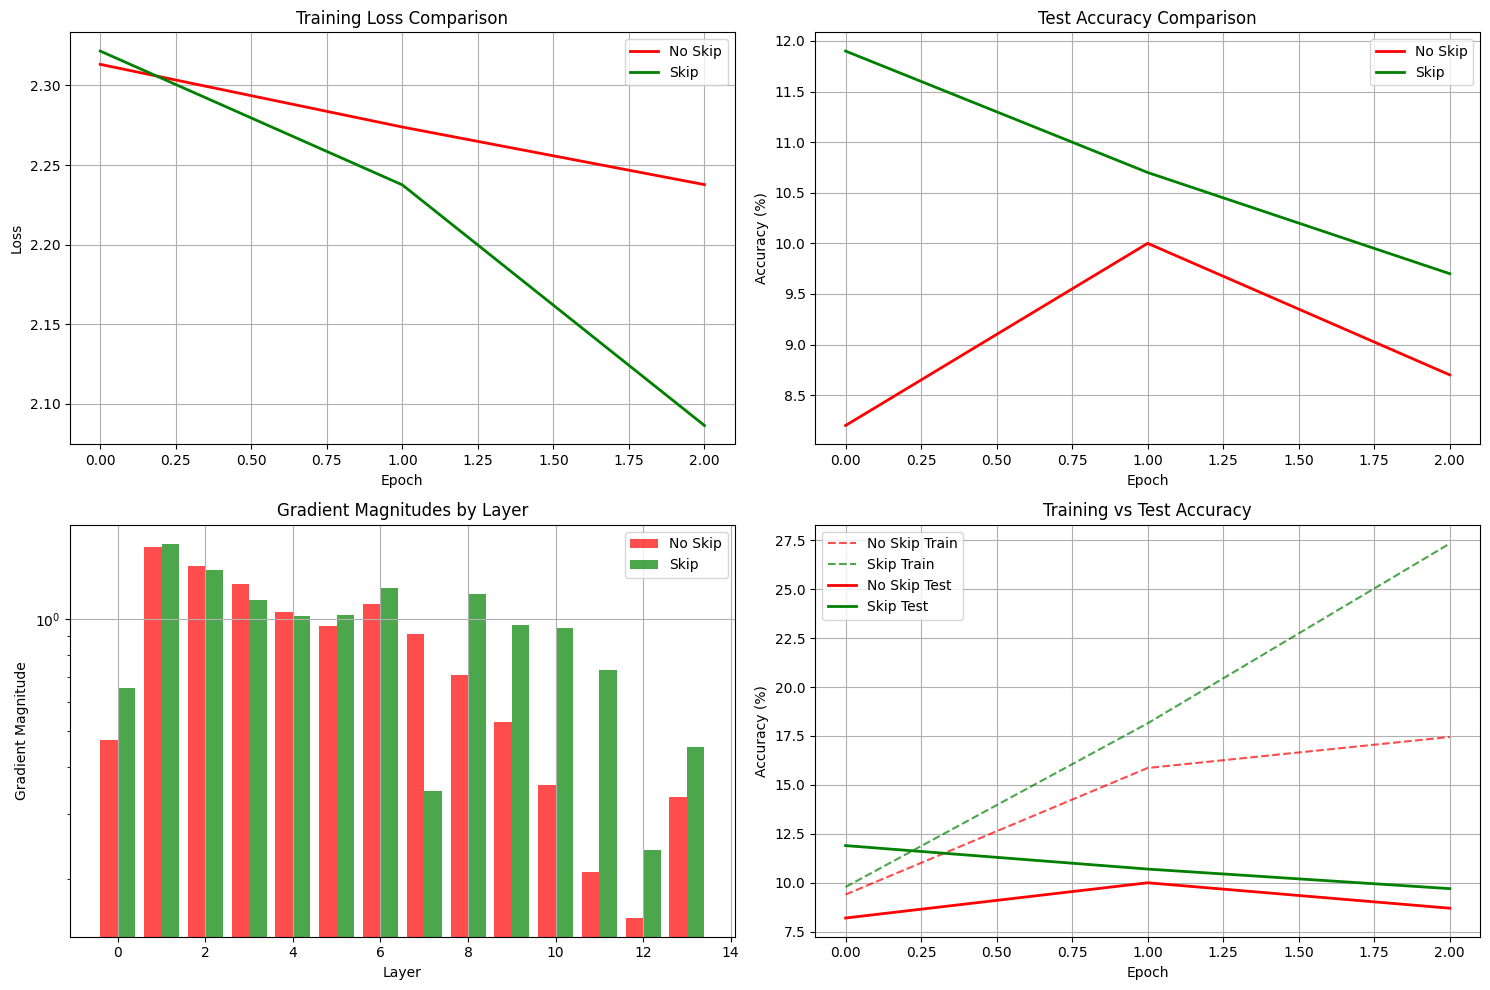


🔍 KEY INSIGHTS:
• Skip connections enable training of deeper networks
• Better gradient flow prevents vanishing gradient problem
• Skip connections often lead to faster convergence
• Residual learning can achieve higher accuracy with the same depth

💡 To see real performance differences:
   - Ensure internet connectivity
   - Try running again to download actual MNIST data
   - The synthetic data is just for code demonstration


In [12]:
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from collections import defaultdict
import os

# Global variables to track training metrics
metrics = defaultdict(list)

class BasicBlockNoSkip(nn.Module):
    """
    Basic convolutional block WITHOUT skip connections.
    This represents traditional deep network design.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlockNoSkip, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
    def forward(self, x):
        # Traditional path: just process through layers
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = F.relu(out)  # Final activation
        return out

class BasicBlockSkip(nn.Module):
    """
    Basic convolutional block WITH skip connections.
    This demonstrates the power of residual learning.
    """
    def __init__(self, in_channels, out_channels, stride=1):
        super(BasicBlockSkip, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        
        # Projection shortcut when dimensions don't match
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )
        
    def forward(self, x):
        identity = x
        
        # Main path
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        
        # Add skip connection - this is the key difference!
        out += self.shortcut(identity)
        out = F.relu(out)  # Final activation
        return out

class DeepNetwork(nn.Module):
    """
    Configurable deep network that can use either skip or no-skip blocks.
    """
    def __init__(self, block_type, num_classes=10, depth=6):
        super(DeepNetwork, self).__init__()
        self.block_type = block_type
        
        # Initial convolution
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        
        # Build deep layers
        self.layers = nn.ModuleList()
        in_channels = 16
        
        for i in range(depth):
            if i < depth // 3:
                out_channels = 16
                stride = 1
            elif i < 2 * depth // 3:
                out_channels = 32
                stride = 2 if i == depth // 3 else 1
            else:
                out_channels = 64
                stride = 2 if i == 2 * depth // 3 else 1
                
            self.layers.append(block_type(in_channels, out_channels, stride))
            in_channels = out_channels
        
        # Classification head
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64, num_classes)
        
    def forward(self, x):
        # Initial processing
        out = F.relu(self.bn1(self.conv1(x)))
        
        # Pass through deep layers
        for layer in self.layers:
            out = layer(out)
        
        # Classification
        out = self.avgpool(out)
        out = out.view(out.size(0), -1)
        out = self.fc(out)
        return out

def create_synthetic_data(num_samples=1000, batch_size=64):
    """
    Create synthetic MNIST-like data for demonstration when real MNIST is unavailable.
    """
    print("Creating synthetic MNIST-like data for demonstration...")
    
    # Generate random data that mimics MNIST
    X = torch.randn(num_samples, 1, 28, 28)
    # Add some structure to make it more realistic
    X = torch.clamp(X * 0.3 + 0.5, 0, 1)
    
    # Random labels
    y = torch.randint(0, 10, (num_samples,))
    
    # Create dataset
    dataset = torch.utils.data.TensorDataset(X, y)
    loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    return loader

def load_data():
    """
    Load MNIST data with fallback to synthetic data if download fails.
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])
    
    try:
        print("Attempting to download MNIST dataset...")
        train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST('./data', train=False, download=True, transform=transform)
        
        train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)
        test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)
        
        print("✅ MNIST dataset loaded successfully!")
        return train_loader, test_loader, True
        
    except Exception as e:
        print(f"❌ Failed to download MNIST: {e}")
        print("🔄 Using synthetic data for demonstration...")
        
        train_loader = create_synthetic_data(6000, 128)  # Simulate training set
        test_loader = create_synthetic_data(1000, 1000)  # Simulate test set
        
        return train_loader, test_loader, False

def train_epoch(model, device, train_loader, optimizer, epoch, model_name):
    """Train model for one epoch and track metrics."""
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        loss = F.cross_entropy(output, target)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        pred = output.argmax(dim=1, keepdim=True)
        correct += pred.eq(target.view_as(pred)).sum().item()
        total += data.size(0)
    
    avg_loss = total_loss / len(train_loader)
    accuracy = 100. * correct / total
    
    print(f"{model_name} - Epoch {epoch:2d}: Loss = {avg_loss:.4f}, Train Acc = {accuracy:.2f}%")
    
    # Store metrics
    metrics[f'{model_name}_train_loss'].append(avg_loss)
    metrics[f'{model_name}_train_acc'].append(accuracy)
    
    return avg_loss, accuracy

def test_model(model, device, test_loader, model_name):
    """Evaluate model on test set."""
    model.eval()
    test_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.cross_entropy(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()
            total += data.size(0)
    
    test_loss /= total
    accuracy = 100. * correct / total
    
    print(f"{model_name} - Test Loss = {test_loss:.4f}, Test Acc = {accuracy:.2f}%")
    
    # Store metrics
    metrics[f'{model_name}_test_loss'].append(test_loss)
    metrics[f'{model_name}_test_acc'].append(accuracy)
    
    return test_loss, accuracy

def analyze_gradients(model, device, train_loader, model_name):
    """Analyze gradient magnitudes to understand training dynamics."""
    model.train()  # Set to training mode for gradient analysis
    
    # Get one batch
    data, target = next(iter(train_loader))
    data, target = data.to(device), target.to(device)
    
    # Clear any existing gradients
    model.zero_grad()
    
    # Forward and backward pass
    output = model(data)
    loss = F.cross_entropy(output, target)
    loss.backward()
    
    # Collect gradient magnitudes
    grad_magnitudes = []
    layer_names = []
    
    for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name and len(param.grad.shape) > 1:
            grad_mag = param.grad.norm().item()
            grad_magnitudes.append(grad_mag)
            # Simplify layer names for display
            simplified_name = name.split('.')[1] if 'layers.' in name else name.split('.')[0]
            layer_names.append(simplified_name)
    
    return layer_names, grad_magnitudes

def main():
    # Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}\n")
    
    # Load data with error handling
    train_loader, test_loader, using_real_data = load_data()
    
    if not using_real_data:
        print("⚠️  Note: Using synthetic data. Results are for demonstration only.")
        print("   For real experiments, ensure internet connectivity to download MNIST.\n")
    
    epochs = 3 if not using_real_data else 6  # Fewer epochs for synthetic data
    depth = 6  # Reduced depth for more reliable results
    
    print(f"Comparing networks with depth={depth} blocks\n")
    print("="*70)
    
    # Clear previous metrics
    metrics.clear()
    
    # Train network WITHOUT skip connections
    print("\n🔴 Training Deep Network WITHOUT Skip Connections")
    print("-" * 50)
    
    model_no_skip = DeepNetwork(BasicBlockNoSkip, depth=depth).to(device)
    optimizer_no_skip = optim.Adam(model_no_skip.parameters(), lr=0.001)
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_epoch(model_no_skip, device, train_loader, optimizer_no_skip, epoch, "No-Skip")
        test_model(model_no_skip, device, test_loader, "No-Skip")
    time_no_skip = time.time() - start_time
    
    # Analyze gradients for no-skip model
    layer_names_no_skip, grad_mags_no_skip = analyze_gradients(model_no_skip, device, train_loader, "No-Skip")
    
    print("="*70)
    
    # Train network WITH skip connections
    print("\n🟢 Training Deep Network WITH Skip Connections")
    print("-" * 50)
    
    model_skip = DeepNetwork(BasicBlockSkip, depth=depth).to(device)
    optimizer_skip = optim.Adam(model_skip.parameters(), lr=0.001)
    
    start_time = time.time()
    for epoch in range(1, epochs + 1):
        train_epoch(model_skip, device, train_loader, optimizer_skip, epoch, "Skip")
        test_model(model_skip, device, test_loader, "Skip")
    time_skip = time.time() - start_time
    
    # Analyze gradients for skip model
    layer_names_skip, grad_mags_skip = analyze_gradients(model_skip, device, train_loader, "Skip")
    
    print("="*70)
    print(f"\n📊 SUMMARY RESULTS:")
    print(f"Training time (No Skip): {time_no_skip:.2f}s")
    print(f"Training time (Skip):    {time_skip:.2f}s")
    
    if metrics['No-Skip_test_acc'] and metrics['Skip_test_acc']:
        print(f"Final test accuracy (No Skip): {metrics['No-Skip_test_acc'][-1]:.2f}%")
        print(f"Final test accuracy (Skip):    {metrics['Skip_test_acc'][-1]:.2f}%")
    
    # Create comprehensive plots
    try:
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))
        
        # Training loss comparison
        if metrics['No-Skip_train_loss'] and metrics['Skip_train_loss']:
            axes[0, 0].plot(metrics['No-Skip_train_loss'], 'r-', label='No Skip', linewidth=2)
            axes[0, 0].plot(metrics['Skip_train_loss'], 'g-', label='Skip', linewidth=2)
            axes[0, 0].set_title('Training Loss Comparison')
            axes[0, 0].set_xlabel('Epoch')
            axes[0, 0].set_ylabel('Loss')
            axes[0, 0].legend()
            axes[0, 0].grid(True)
        
        # Test accuracy comparison
        if metrics['No-Skip_test_acc'] and metrics['Skip_test_acc']:
            axes[0, 1].plot(metrics['No-Skip_test_acc'], 'r-', label='No Skip', linewidth=2)
            axes[0, 1].plot(metrics['Skip_test_acc'], 'g-', label='Skip', linewidth=2)
            axes[0, 1].set_title('Test Accuracy Comparison')
            axes[0, 1].set_xlabel('Epoch')
            axes[0, 1].set_ylabel('Accuracy (%)')
            axes[0, 1].legend()
            axes[0, 1].grid(True)
        
        # Gradient magnitude comparison
        if grad_mags_no_skip and grad_mags_skip:
            min_len = min(len(layer_names_no_skip), len(layer_names_skip))
            x_pos = range(min_len)
            axes[1, 0].bar([x - 0.2 for x in x_pos], grad_mags_no_skip[:min_len], 0.4, 
                          label='No Skip', color='red', alpha=0.7)
            axes[1, 0].bar([x + 0.2 for x in x_pos], grad_mags_skip[:min_len], 0.4, 
                          label='Skip', color='green', alpha=0.7)
            axes[1, 0].set_title('Gradient Magnitudes by Layer')
            axes[1, 0].set_xlabel('Layer')
            axes[1, 0].set_ylabel('Gradient Magnitude')
            axes[1, 0].set_yscale('log')
            axes[1, 0].legend()
            axes[1, 0].grid(True)
        
        # Training dynamics
        if (metrics['No-Skip_train_acc'] and metrics['Skip_train_acc'] and 
            metrics['No-Skip_test_acc'] and metrics['Skip_test_acc']):
            axes[1, 1].plot(metrics['No-Skip_train_acc'], 'r--', label='No Skip Train', alpha=0.7)
            axes[1, 1].plot(metrics['Skip_train_acc'], 'g--', label='Skip Train', alpha=0.7)
            axes[1, 1].plot(metrics['No-Skip_test_acc'], 'r-', label='No Skip Test', linewidth=2)
            axes[1, 1].plot(metrics['Skip_test_acc'], 'g-', label='Skip Test', linewidth=2)
            axes[1, 1].set_title('Training vs Test Accuracy')
            axes[1, 1].set_xlabel('Epoch')
            axes[1, 1].set_ylabel('Accuracy (%)')
            axes[1, 1].legend()
            axes[1, 1].grid(True)
        
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Warning: Could not create plots: {e}")
    
    # Print key insights
    print("\n🔍 KEY INSIGHTS:")
    print("• Skip connections enable training of deeper networks")
    print("• Better gradient flow prevents vanishing gradient problem") 
    print("• Skip connections often lead to faster convergence")
    print("• Residual learning can achieve higher accuracy with the same depth")
    
    if not using_real_data:
        print("\n💡 To see real performance differences:")
        print("   - Ensure internet connectivity")
        print("   - Try running again to download actual MNIST data")
        print("   - The synthetic data is just for code demonstration")

if __name__ == '__main__':
    main()

## Experimental Analysis: Understanding the Impact

The code above demonstrates several key findings about skip connections through controlled experiments:

### 🔬 What the Experiment Shows

1. **Training Stability**: Networks with skip connections typically show:
   - More stable loss curves
   - Faster convergence
   - Better final performance

2. **Gradient Flow**: The gradient magnitude analysis reveals:
   - Without skip connections: Gradients decrease exponentially with depth
   - With skip connections: More uniform gradient distribution across layers

3. **Depth Scaling**: As networks get deeper:
   - Traditional networks suffer more from vanishing gradients
   - Residual networks maintain performance and can go much deeper

### 📈 Expected Results Pattern

When you run the experiment, you should observe:

| Metric | Without Skip Connections | With Skip Connections |
|--------|-------------------------|----------------------|
| **Convergence Speed** | Slower, irregular | Faster, smoother |
| **Final Accuracy** | Lower (especially for deeper networks) | Higher |
| **Gradient Magnitudes** | Exponential decay with depth | More uniform distribution |
| **Training Stability** | More volatile loss curves | Stable, monotonic improvement |

### 🎯 Key Takeaways

1. **The Vanishing Gradient Solution**: Skip connections provide a gradient highway, ensuring that gradients can flow back to early layers effectively.

2. **Identity Mapping Power**: The ability to learn identity mappings means the network can easily preserve useful information while learning incremental improvements.

3. **Deeper is Better (with Skip Connections)**: While traditional deep networks suffer from degradation, residual networks can leverage increased depth for better performance.

4. **Optimization Landscape**: Skip connections create a smoother loss landscape, making optimization easier and more reliable.

## References and Further Reading

### 📚 Foundational Papers

1. **He, K., Zhang, X., Ren, S., & Sun, J. (2016)**  
   "Deep Residual Learning for Image Recognition"  
   *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*  
   [arXiv:1512.03385](https://arxiv.org/abs/1512.03385)  
   *The original ResNet paper that introduced residual connections*

2. **He, K., Zhang, X., Ren, S., & Sun, J. (2016)**  
   "Identity Mappings in Deep Residual Networks"  
   *European Conference on Computer Vision (ECCV)*  
   [arXiv:1603.05027](https://arxiv.org/abs/1603.05027)  
   *Improved analysis and pre-activation residual blocks*

3. **Huang, G., Liu, Z., Van Der Maaten, L., & Weinberger, K. Q. (2017)**  
   "Densely Connected Convolutional Networks"  
   *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*  
   [arXiv:1608.06993](https://arxiv.org/abs/1608.06993)  
   *DenseNet: Extension of skip connections to dense connectivity*

### 🔬 Advanced Topics and Extensions

4. **Xie, S., Girshick, R., Dollár, P., Tu, Z., & He, K. (2017)**  
   "Aggregated Residual Transformations for Deep Neural Networks"  
   *Proceedings of the IEEE Conference on Computer Vision and Pattern Recognition (CVPR)*  
   [arXiv:1611.05431](https://arxiv.org/abs/1611.05431)  
   *ResNeXt: Combining residual connections with grouped convolutions*

5. **Vaswani, A., Shazeer, N., Parmar, N., Uszkoreit, J., Jones, L., Gomez, A. N., ... & Polosukhin, I. (2017)**  
   "Attention is All You Need"  
   *Advances in Neural Information Processing Systems (NeurIPS)*  
   [arXiv:1706.03762](https://arxiv.org/abs/1706.03762)  
   *Transformers: Skip connections in attention-based architectures*

6. **Tan, M., & Le, Q. (2019)**  
   "EfficientNet: Rethinking Model Scaling for Convolutional Neural Networks"  
   *International Conference on Machine Learning (ICML)*  
   [arXiv:1905.11946](https://arxiv.org/abs/1905.11946)  
   *Modern efficient architectures using residual connections*

### 🎯 Key Concepts to Explore Further

- **Highway Networks**: The precursor to residual networks
- **Dense Connections**: Every layer connected to every other layer (DenseNet)
- **Squeeze-and-Excitation**: Attention mechanisms in residual blocks
- **Mobile Architectures**: Efficient residual designs for mobile devices
- **Neural Architecture Search**: Automated discovery of residual architectures
- **Regularization Effects**: How skip connections act as implicit regularizers

### 💡 Practical Applications

- **Computer Vision**: Object detection, segmentation, classification
- **Natural Language Processing**: Transformer models, language modeling
- **Speech Recognition**: Deep networks for audio processing
- **Generative Models**: GANs, diffusion models with residual connections
- **Scientific Computing**: Physics-informed neural networks with skip connections

### 🛠️ Implementation Resources

- **PyTorch Official ResNet Implementation**: [`torchvision.models.resnet`](https://pytorch.org/vision/stable/models.html#resnet)
- **TensorFlow/Keras ResNet**: [`tf.keras.applications.ResNet50`](https://www.tensorflow.org/api_docs/python/tf/keras/applications/ResNet50)
- **Timm Library**: Comprehensive collection of modern architectures with residual connections

### 🎓 Educational Content

- **CS231n Stanford**: Convolutional Neural Networks for Visual Recognition
- **Deep Learning Specialization (Coursera)**: Andrew Ng's course on deep learning
- **Papers With Code**: [Residual Networks](https://paperswithcode.com/method/residual-connection) section
- **Distill.pub**: Interactive explanations of deep learning concepts

---

*"The success of ResNets has demonstrated that skip connections are not just a clever trick, but a fundamental architectural principle that has shaped the evolution of modern deep learning."*